In [25]:
import numpy as np
import pandas as pd

In [26]:
class Logistic_reg_trick_own:
    def __init__(self,learning_rate=0.01,epochs=100):
        self.lr=learning_rate
        self.epoch=epochs
        self.coef=None
        # intercept is handled well with coefs only 
    
    def fit(self,X,y):
        # initializing coefs
        self.coef=np.ones(X.shape[1]+1)

        # adding ones as the first row in X
        # that is their to handle constant term easily
        X=np.insert(X,0,1,axis=1) # arr,col,val,axis

        for i in range(self.epoch):
            ind=np.random.randint(0,X.shape[0])

            if y[ind]>0 and np.dot(self.coef.T,X[ind])<=0:
                self.coef=self.coef+(self.lr*X[ind])
                continue
            if y[ind]<=0 and np.dot(self.coef.T,X[ind])>0:
                self.coef=self.coef-(self.lr*X[ind])
                continue

    def predict(self,X):
        X=np.insert(X,0,1,axis=1)
        return np.dot(X,self.coef)>=0 # greater than equal to zero meaning 
    # greater than equal to zero meaning selction happended else didnt


In [ ]:
class trick_simplified:
    def __init__(self,learning_rate=0.01,epochs=1000):
        self.lr=learning_rate
        self.epoch=epochs
        self.coef=None
        # intercept is again handled with coef arr later
    
    def check(self,num):
        if num>=0:
            return 1
        return 0
    
    def fit(self,X,y):
        # initilizing coefs and bias together
        self.coef=np.ones(X.shape[1]+1)

        # adding ones to X to handle everything easily
        X=np.insert(X,0,1,axis=1)

        for i in range(self.epoch):
            ind=np.random.randint(0,X.shape[0])

            y_pred=self.check(np.dot(X[ind],self.coef))

            self.coef=self.coef+(self.lr*(y[ind]-y_pred)*X[ind])

            print(self.coef[0],self.coef[1:])
            # self.coef[0] is the coef
            
    def predict(self,X):
        X=np.insert(X,0,1,axis=1)
        return np.dot(X,self.coef)>=0


In [28]:
import numpy as np

X = np.array([
    [1, 1],
    [2, 1],
    [2, 2],
    [3, 2],
    [6, 5],
    [7, 6],
    [8, 6],
    [9, 7]
])

y = np.array([
    0, 0, 0, 0,
    1, 1, 1, 1
])

In [29]:
model1=Logistic_reg_trick_own()
model2=trick_simplified()

model1.fit(X,y)
model2.fit(X,y)

1.0 [1. 1.]
0.99 [0.99 0.99]
0.98 [0.96 0.97]
0.98 [0.96 0.97]
0.98 [0.96 0.97]
0.97 [0.93 0.95]
0.97 [0.93 0.95]
0.97 [0.93 0.95]
0.97 [0.93 0.95]
0.96 [0.91 0.93]
0.95 [0.89 0.91]
0.94 [0.86 0.89]
0.9299999999999999 [0.85 0.88]
0.9199999999999999 [0.84 0.87]
0.9199999999999999 [0.84 0.87]
0.9199999999999999 [0.84 0.87]
0.9099999999999999 [0.81 0.85]
0.8999999999999999 [0.79 0.83]
0.8899999999999999 [0.78 0.82]
0.8799999999999999 [0.76 0.81]
0.8699999999999999 [0.74 0.79]
0.8599999999999999 [0.72 0.77]
0.8499999999999999 [0.7  0.75]
0.8499999999999999 [0.7  0.75]
0.8399999999999999 [0.68 0.73]
0.8299999999999998 [0.65 0.71]
0.8299999999999998 [0.65 0.71]
0.8299999999999998 [0.65 0.71]
0.8199999999999998 [0.64 0.7 ]
0.8199999999999998 [0.64 0.7 ]
0.8199999999999998 [0.64 0.7 ]
0.8099999999999998 [0.62 0.68]
0.8099999999999998 [0.62 0.68]
0.7999999999999998 [0.61 0.67]
0.7999999999999998 [0.61 0.67]
0.7999999999999998 [0.61 0.67]
0.7899999999999998 [0.58 0.65]
0.7899999999999998 [0.58 0

In [30]:
print(model1.predict(X))
print(y)
print(model2.predict(X))
print(model1.coef[0],model1.coef[1:])

[ True  True  True  True  True  True  True  True]
[0 0 0 0 1 1 1 1]
[False False False False  True  True  True  True]
0.47999999999999954 [-0.14  0.17]


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
X_line=np.linspace(0,10,100)
y_line=-(model1.coef[0]+model1.coef[1]*X_line)/model1.coef[2]

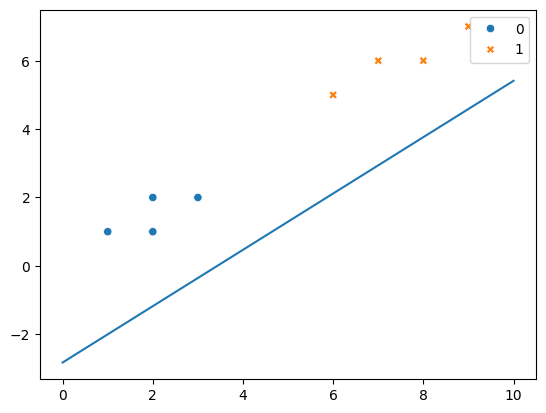

In [33]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y,style=y)
plt.plot(X_line,y_line)